<a href="https://colab.research.google.com/github/khadijaelewa/bachelorproject/blob/main/enhancements2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Acquisition & Setup

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd

path = "/content/drive/MyDrive/enhancement/"

df = pd.read_csv(path + "student_performance.csv")

df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [31]:
path = "/content/drive/MyDrive/enhancement/"
df = pd.read_csv(path + "student_performance.csv")

# Data Exploration & Understanding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

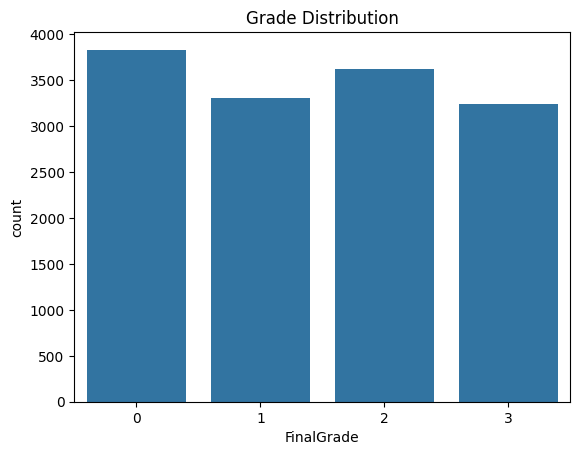

In [32]:
print(df.info())
print(df.describe())

# Target distribution
sns.countplot(x='FinalGrade', data=df)
plt.title("Grade Distribution")
plt.show()

# Target Variable Engineering

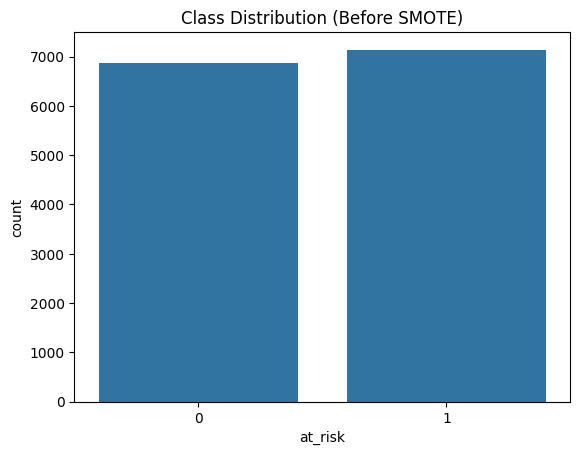

In [33]:
df['at_risk'] = df['FinalGrade'].apply(lambda x: 1 if x < 2 else 0)

sns.countplot(x='at_risk', data=df)
plt.title("Class Distribution (Before SMOTE)")
plt.show()

# Exploratory Data Analysis (EDA)

In [34]:
df = df.drop(columns=['FinalGrade','ExamScore','AssignmentCompletion'])

In [35]:
X = df.drop(columns=['at_risk'])
y = df['at_risk']

X = pd.get_dummies(X, drop_first=True)

# Train-Test Splitting Strategy

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Feature Scaling & Transformation

In [37]:
scaler = PowerTransformer()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handling Class Imbalance (SMOTE)

In [50]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
at_risk
1    5713
0    5489
Name: count, dtype: int64


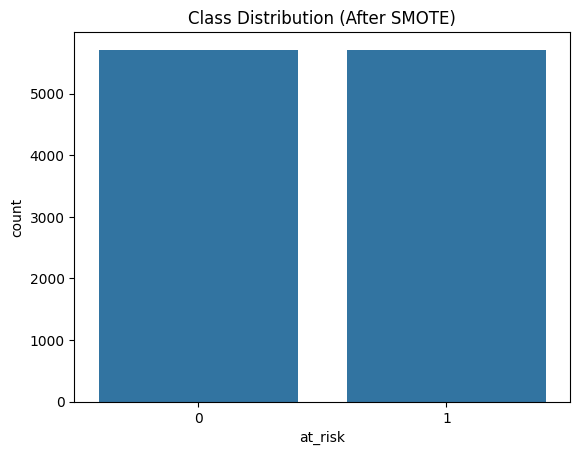

In [38]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

sns.countplot(x=y_train_res)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [51]:
print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

After SMOTE:
at_risk
1    5713
0    5713
Name: count, dtype: int64


# Model Development

In [39]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(xgb, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


# Model Validation (Cross-Validation)

In [40]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train_res, y_train_res, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

Cross-validation F1 scores: [0.76272649 0.778685   0.75010903 0.78475531 0.76849434]
Mean CV F1: 0.7689540332418996


# Model Prediction

In [41]:
y_pred = best_xgb.predict(X_test_scaled)
y_probs = best_xgb.predict_proba(X_test_scaled)[:,1]

# Model Evaluation Metrics

In [42]:
threshold = 0.4  # instead of default 0.5

y_pred_custom = (y_probs >= threshold).astype(int)

print("Custom Threshold Report:")
print(classification_report(y_test, y_pred_custom))

Custom Threshold Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1372
           1       0.85      0.94      0.90      1429

    accuracy                           0.89      2801
   macro avg       0.89      0.89      0.89      2801
weighted avg       0.89      0.89      0.89      2801



# Confusion Matrix Analysis

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1372
           1       0.91      0.90      0.91      1429

    accuracy                           0.91      2801
   macro avg       0.91      0.91      0.91      2801
weighted avg       0.91      0.91      0.91      2801



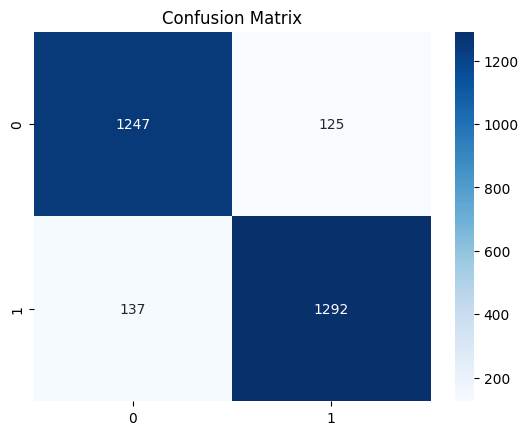

In [43]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve & AUC Analysis

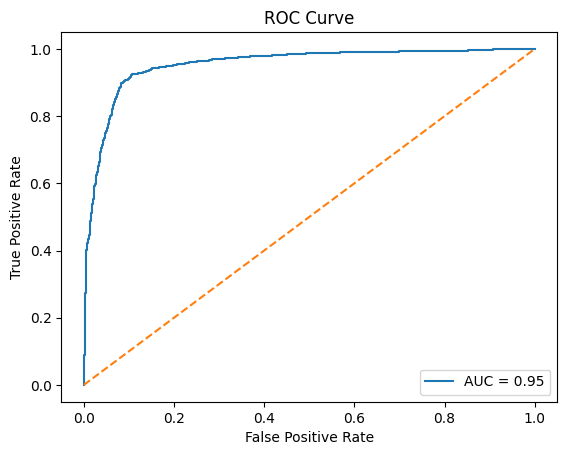

In [44]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [49]:
print("AUC Score:", auc)

AUC Score: 0.9532293373212526


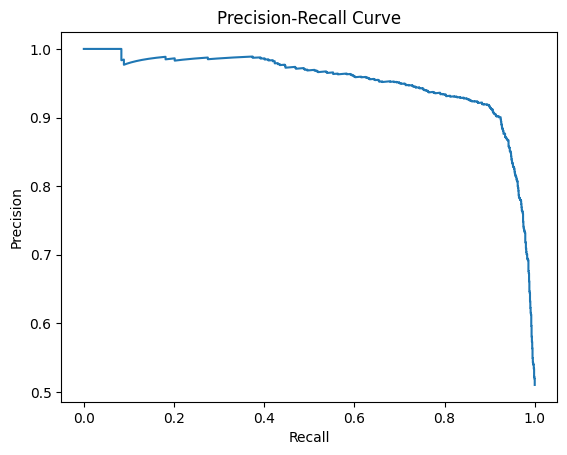

In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Feature Importance Analysis

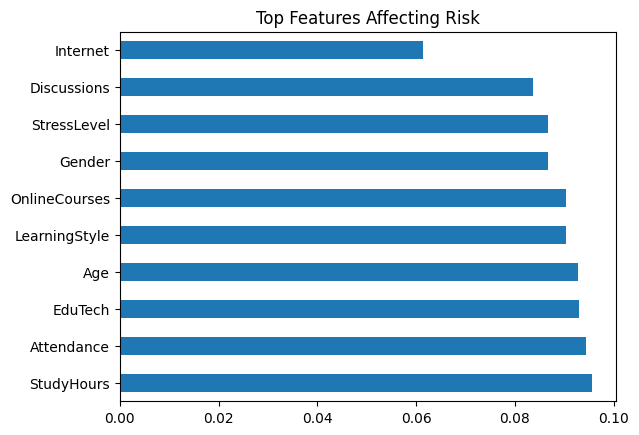

In [46]:
importance = best_xgb.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Top Features Affecting Risk")
plt.show()

In [47]:
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_imp_df.head(10)

,Feature,Importance
10,Discussions,0.098655
0,StudyHours,0.094748
9,OnlineCourses,0.091654
7,Age,0.091554
8,LearningStyle,0.091465
12,StressLevel,0.091348
1,Attendance,0.089760
6,Gender,0.087771
11,EduTech,0.079596
4,Motivation,0.050363


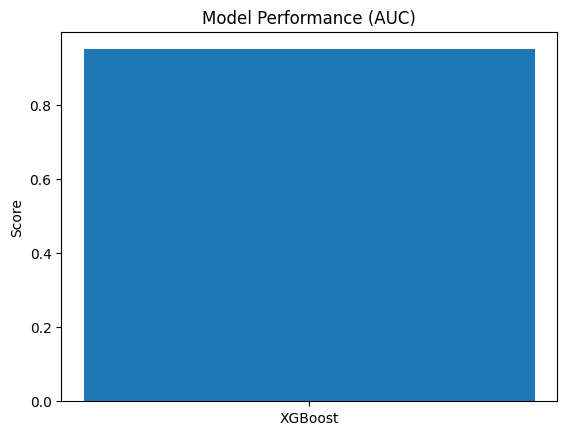

In [48]:
models = ['XGBoost']
scores = [0.95]

plt.bar(models, scores)
plt.title("Model Performance (AUC)")
plt.ylabel("Score")
plt.show()